In [1]:

import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.svm import SVR
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import GroupKFold

c:\Users\hosse\anaconda3\Lib\site-packages\seaborn\_statistics.py:32: UserWarning: A NumPy version >=1.23.5 and <2.5.0 is required for this version of SciPy (detected version 2.5.2)
  from scipy.stats import gaussian_kde


## Modeling Setup

### load datasets

In [2]:
file_names = ['X_train', 'y_train', 'X_val', 'y_val', 'X_test', 'y_test', 'train_engine_ids']

for name in file_names:
    globals()[name] = pd.read_csv(f'data/processed/{name}.csv')

In [3]:
X_train.shape, train_engine_ids.shape, y_train.shape, X_val.shape, y_val.shape, X_test.shape, y_test.shape

((16561, 16),
 (16561, 1),
 (16561, 1),
 (4070, 16),
 (4070, 1),
 (100, 16),
 (100, 1))

In [4]:
y_train = y_train.squeeze()
y_val = y_val.squeeze()
y_test = y_test.squeeze()
train_engine_ids = train_engine_ids.squeeze()

### Define Evaluation Metrics

## Evaluation Metrics

We evaluate performance using MAE, RMSE, R², and the NASA Score.

- **MAE (Mean Absolute Error)**: Average prediction error in cycles. For instance, MAE = 12 indicates our prediction deviates by 12 cycles on average.

- **RMSE (Root Mean Squared Error)**: Penalizes larger errors more heavily than MAE.

- **R² (Coefficient of Determination)**: Explains the proportion of variance in RUL captured by the model. Higher values indicate better performance.

- **NASA Score**: Asymmetric scoring function used in the PHM challenge.

In RUL prediction, errors have unequal costs. Late predictions (overestimating life) are riskier than early ones. Thus, the C-MAPSS/PHM evaluation uses an asymmetric scoring function, penalizing late predictions more heavily than early ones.

The scoring function for C-MAPSS is defined as:

$$
S(d) =
\begin{cases}
e^{-d/13} - 1, & d < 0 \quad \text{(early prediction)} \\
e^{d/10} - 1, & d \ge 0 \quad \text{(late prediction)}
\end{cases}
$$

where $d = \hat{RUL} - RUL$.

In [5]:
def MAE(y_true, y_pred):
    """Mean Absolute Error: average absolute prediction error."""
    return mean_absolute_error(y_true, y_pred)

def RMSE(y_true, y_pred):
    """Root Mean Squared Error: penalizes larger errors more heavily."""
    return root_mean_squared_error(y_true, y_pred)

def R2(y_true, y_pred):
    """R² Score: proportion of variance in RUL explained by the model."""
    return r2_score(y_true, y_pred)

def nasa_score(y_true, y_pred):
    error = y_pred - y_true

    score = np.where(
        error < 0,
        np.exp(-error / 13) - 1,
        np.exp(error / 10) - 1
    )

    return np.sum(score) / len(y_pred)

In [6]:
# make a table of all metrics for a model

def evaluate_model(y_true, y_pred, model_name):
    results = {
        "Model": model_name,
        "↓MAE": MAE(y_true, y_pred),
        "↓RMSE": RMSE(y_true, y_pred),
        "↑R2": R2(y_true, y_pred),
        "↓NASA Score (mean)": nasa_score(y_true, y_pred)
    }
    
    return pd.DataFrame([results]).round(2)

## Baseline Model

### Linear Regression

In [7]:
reg = LinearRegression() 
reg = reg.fit(X_train, y_train)
y_val_pred = reg.predict(X_val)



In [8]:
lr_score = evaluate_model(
    y_val, 
    y_val_pred,
    model_name ="regression"
    )
lr_score

,Model,↓MAE,↓RMSE,↑R2,↓NASA Score (mean)
0,regression,16.51,20.43,0.76,7.09


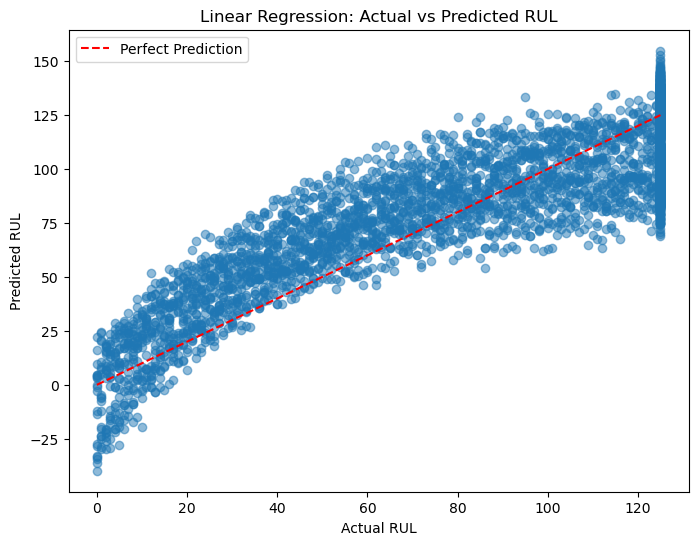

In [9]:
plt.figure(figsize=(8, 6))

plt.scatter(y_val, y_val_pred, alpha=0.5)

plt.plot(
    [y_val.min(), y_val.max()],
    [y_val.min(), y_val.max()],
    linestyle="--",
    color='red',
    label='Perfect Prediction'
)

plt.xlabel("Actual RUL")
plt.ylabel("Predicted RUL")
plt.title("Linear Regression: Actual vs Predicted RUL")
plt.legend()
plt.show()


Observation:
The model works better when the actual RUL is low, and many predictions are close to the perfect prediction line. However, when the actual RUL becomes higher, the model starts to underestimate it. Most predictions stay around 150–190 cycles even when the actual RUL is much higher. This shows that Linear Regression cannot fully capture the more complex relationship between the features and RUL.

## Advanced Models


Since the linear model fails to adequately capture the RUL relationship, we proceed with non-linear models using their default/random initial hyperparameters.


### Random Forest

In [10]:
rf_model = RandomForestRegressor(n_estimators=100,random_state=42, n_jobs=-1)
rf_model = rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_val)



In [11]:
rf_score = evaluate_model(y_val, y_pred_rf, "Random Forest")
rf_score


,Model,↓MAE,↓RMSE,↑R2,↓NASA Score (mean)
0,Random Forest,12.56,17.21,0.83,7.96


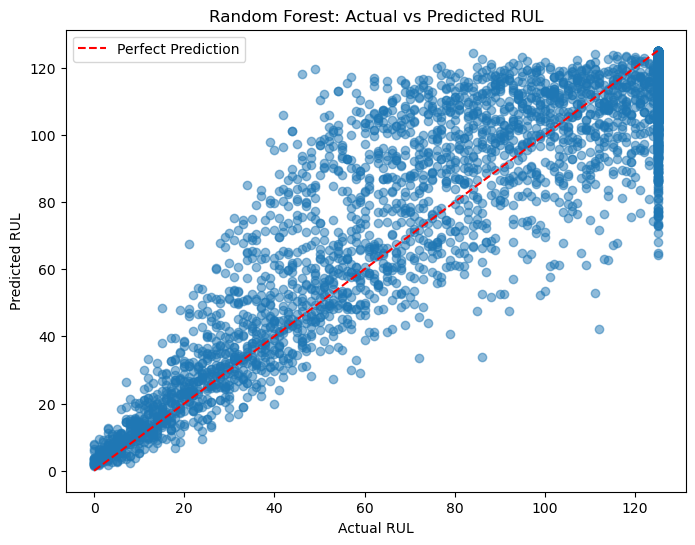

In [12]:
plt.figure(figsize=(8, 6))

plt.scatter(y_val, y_pred_rf, alpha=0.5)

plt.plot(
    [y_val.min(), y_val.max()],
    [y_val.min(), y_val.max()],
    linestyle="--",
    color='red',
    label='Perfect Prediction'
)

plt.xlabel("Actual RUL")
plt.ylabel("Predicted RUL")
plt.title("Random Forest: Actual vs Predicted RUL")
plt.legend()
plt.show()

### Gradient Boosting

In [13]:
gb_model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)
gb_model = gb_model.fit(X_train, y_train)
y_pred_gb = gb_model.predict(X_val)

In [14]:
gb_score = evaluate_model(y_val, y_pred_gb, "Gradient Boosting")
gb_score

,Model,↓MAE,↓RMSE,↑R2,↓NASA Score (mean)
0,Gradient Boosting,12.54,17.06,0.83,7.23


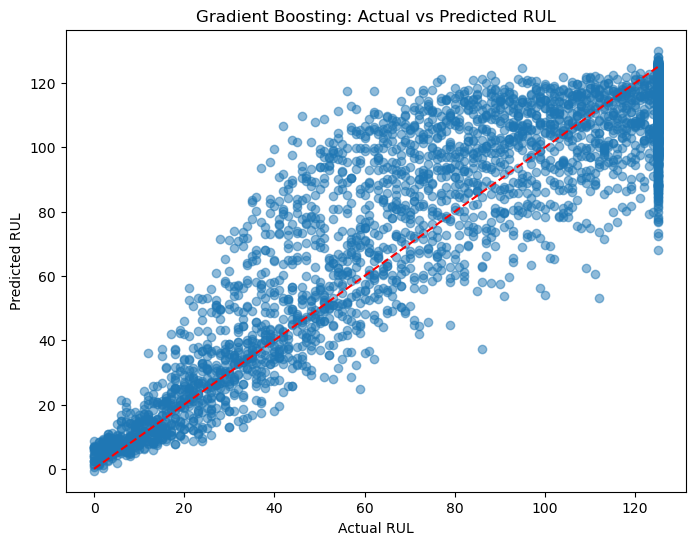

In [15]:
plt.figure(figsize=(8, 6))

plt.scatter(y_val, y_pred_gb, alpha=0.5)

plt.plot(
    [y_val.min(), y_val.max()],
    [y_val.min(), y_val.max()],
    linestyle="--",
    color='red',  
)

plt.xlabel("Actual RUL")
plt.ylabel("Predicted RUL")
plt.title("Gradient Boosting: Actual vs Predicted RUL")

plt.show()

### XGBoost

In [16]:
xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)
xgb_model = xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_val)

In [17]:
xgb_score = evaluate_model(y_val, y_pred_xgb, "XGBoost")
xgb_score

,Model,↓MAE,↓RMSE,↑R2,↓NASA Score (mean)
0,XGBoost,12.18,16.97,0.83,8.37


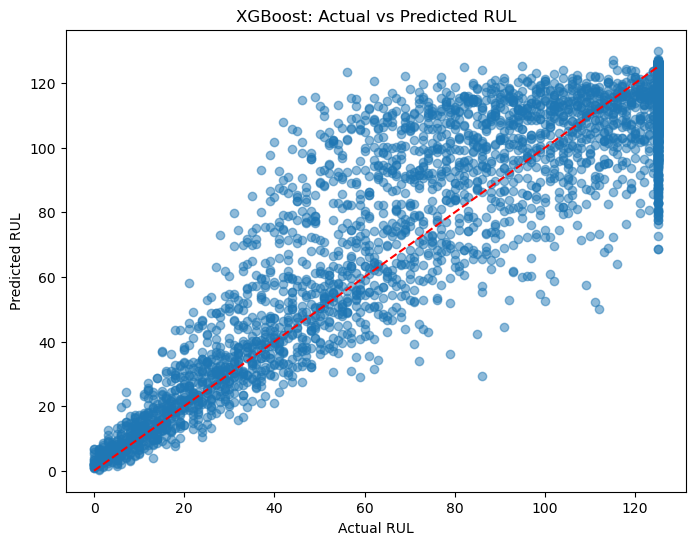

In [18]:
plt.figure(figsize=(8, 6))

plt.scatter(y_val, y_pred_xgb, alpha=0.5)

plt.plot(
    [y_val.min(), y_val.max()],
    [y_val.min(), y_val.max()],
    linestyle="--",
    color='red',
)

plt.xlabel("Actual RUL")
plt.ylabel("Predicted RUL")
plt.title("XGBoost: Actual vs Predicted RUL")

plt.show()

### SVR (support vector machine)

In [19]:
svr_model = SVR(kernel='rbf')
svr_model = svr_model.fit(X_train, y_train)
y_pred_svr = svr_model.predict(X_val)

In [20]:
svr_score = evaluate_model(y_val, y_pred_svr, "SVR")
svr_score

,Model,↓MAE,↓RMSE,↑R2,↓NASA Score (mean)
0,SVR,12.19,17.49,0.82,10.92


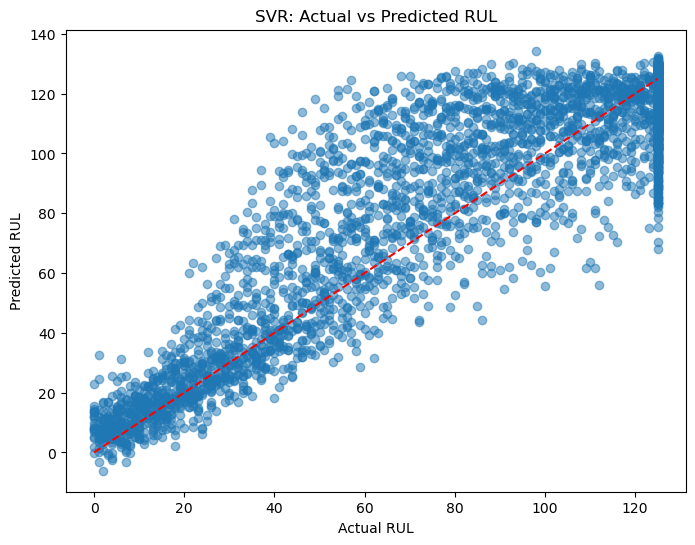

In [21]:
plt.figure(figsize=(8, 6))

plt.scatter(y_val, y_pred_svr, alpha=0.5)

plt.plot(
    [y_val.min(), y_val.max()],
    [y_val.min(), y_val.max()],
    linestyle="--",
    color='red',
)

plt.xlabel("Actual RUL")
plt.ylabel("Predicted RUL")
plt.title("SVR: Actual vs Predicted RUL")

plt.show()

### Initial Model Comparison

In [22]:
all_scores = [lr_score, rf_score, gb_score, xgb_score, svr_score]

final_results = pd.concat(all_scores, ignore_index=True)

final_results.sort_values("↓NASA Score (mean)").reset_index(drop=True)

,Model,↓MAE,↓RMSE,↑R2,↓NASA Score (mean)
0,regression,16.51,20.43,0.76,7.09
1,Gradient Boosting,12.54,17.06,0.83,7.23
2,Random Forest,12.56,17.21,0.83,7.96
3,XGBoost,12.18,16.97,0.83,8.37
4,SVR,12.19,17.49,0.82,10.92



Five baseline models were evaluated with default hyperparameters. Results (see table above) show that Gradient Boosting and XGBoost outperform the others across all metrics.

Both models achieve similar RMSE (~35.5) and R² (~0.71), but Gradient Boosting achieves a significantly lower NASA Score, indicating better performance under the asymmetric penalty function (fewer risky late predictions). SVR and Linear Regression lag behind, confirming the need for non-linear modeling.

Based on these results, we select **Gradient Boosting** and **XGBoost** for hyperparameter tuning to further improve performance.
and we select **Random Forest** as benchmark.

## 4. Model Evolution

### Error Analysis

Error = Prediction − Actual

Distribution of errors

Early vs Late predictions

Maximum errors

Error vs Actual RUL

In [23]:
error_gb = y_pred_gb - y_val
error_xgb = y_pred_xgb - y_val

Text(0.5, 1.0, 'XGBoost Error Distribution')

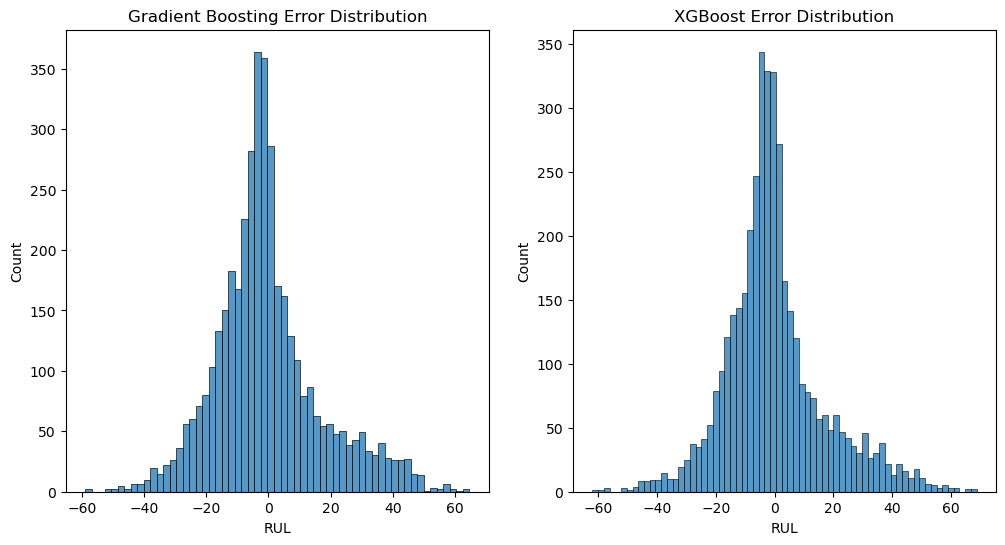

In [24]:
fig , ax = plt.subplots(1,2 , figsize = (12,6))
sns.histplot(error_gb, ax = ax[0])
sns.histplot(error_xgb, ax= ax[1])

ax[0].set_title(f"Gradient Boosting Error Distribution")
ax[1].set_title(f"XGBoost Error Distribution")

### Feature Importance Analysis

usage of each model from features

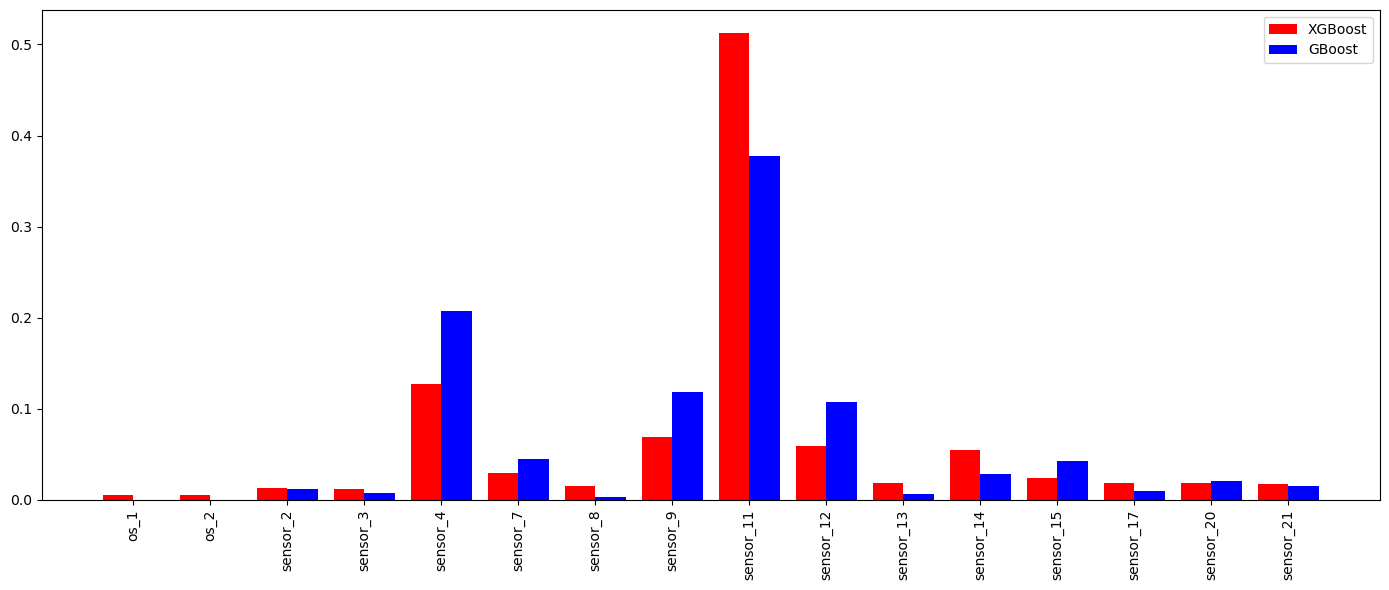

In [25]:
x = np.arange(len(X_train.columns)) 
width = 0.4  

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(x - width/2, xgb_model.feature_importances_, width, label='XGBoost', color='red')
ax.bar(x + width/2, gb_model.feature_importances_, width, label='GBoost', color='blue')

ax.set_xticks(x)
ax.set_xticklabels(X_train.columns, rotation=90)
ax.legend()
plt.tight_layout()
plt.show()

It is evident that sensor 11 has the highest importance in both models, followed by sensors 4, 9, and 12.

### Hyperparameter Tuning (RandomizedSearchCV)

#### XGBoost

In [26]:
# Define NASA Score as the scoring metric for hyperparameter tuning
from sklearn.metrics import make_scorer
nasa_scorer = make_scorer(nasa_score, greater_is_better=False)

# # Group-based cross-validation
group_kfold = GroupKFold(n_splits=3)
train_engine_ids = train_engine_ids.squeeze()

In [28]:

xgb_param_dist = {
    "n_estimators": [200, 300, 400, 500],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "max_depth": [3, 4, 5, 6, 8],
    "min_child_weight": [1, 3, 5],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0]
}

xgb_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=xgb_param_dist,
    n_iter=100,
    scoring=nasa_scorer,
    cv=group_kfold,
    random_state=42,
    n_jobs=-1,
    verbose=1
)
xgb_search.fit(X_train, y_train, groups=train_engine_ids)

Fitting 3 folds for each of 100 candidates, totalling 300 fits


RandomizedSearchCV(cv=GroupKFold(n_splits=3, random_state=None, shuffle=False),
                   estimator=XGBRegressor(base_score=None, booster=None,
                                          callbacks=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=0.8, device=None,
                                          early_stopping_rounds=None,
                                          enable_categorical=True,
                                          eval_metric=None, feature_types=None,
                                          feature_weights=None, gamma=None,
                                          grow_poli...
                                          n_jobs=-1, num_parallel_tree=None, ...),
                   n_iter=100, n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.7, 0.8, 0.9,
                                                             1.0],
                                        'learning_rate': [0.01, 0.03, 0.05,
                                                          0.1],
                                        'max_depth': [3, 4, 5, 6, 8],
                                        'min_child_weight': [1, 3, 5],
                                        'n_estimators': [200, 300, 400, 500],
                                        'subsample': [0.7, 0.8, 0.9, 1.0]},
                   random_state=42,
                   scoring=make_scorer(nasa_score, greater_is_better=False, response_method='predict'),
                   verbose=1)

In [29]:
print("Best CV NASA Score:", -xgb_search.best_score_)

Best CV NASA Score: 12.16375073361585


In [30]:
best_xgb = xgb_search.best_estimator_

y_val_pred_xgb_tuned = best_xgb.predict(X_val)

xgb_tuned_score = evaluate_model(
    y_val,
    y_val_pred_xgb_tuned,
    "xgb_tuned"
)

xgb_tuned_score

,Model,↓MAE,↓RMSE,↑R2,↓NASA Score (mean)
0,xgb_tuned,14.71,17.88,0.82,7.19


### Gradient Boosting

In [31]:
gb_param_dist = {
    "n_estimators": [100, 200, 300, 400, 500],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "max_depth": [2, 3, 4, 5],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "subsample": [0.7, 0.8, 0.9, 1.0]
}

gb_search = RandomizedSearchCV(
    estimator=gb_model,
    param_distributions=gb_param_dist,
    n_iter=100,
    scoring=nasa_scorer,
    cv=group_kfold,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

gb_search.fit(X_train, y_train, groups=train_engine_ids)

Fitting 3 folds for each of 100 candidates, totalling 300 fits


RandomizedSearchCV(cv=GroupKFold(n_splits=3, random_state=None, shuffle=False),
                   estimator=GradientBoostingRegressor(learning_rate=0.05,
                                                       n_estimators=200,
                                                       random_state=42),
                   n_iter=100, n_jobs=-1,
                   param_distributions={'learning_rate': [0.01, 0.03, 0.05,
                                                          0.1],
                                        'max_depth': [2, 3, 4, 5],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [100, 200, 300, 400,
                                                         500],
                                        'subsample': [0.7, 0.8, 0.9, 1.0]},
                   random_state=42,
                   scoring=make_scorer(nasa_score, greater_is_better=False, response_method='predict'),
                   verbose=1)

In [32]:
print("Best CV NASA Score:", -gb_search.best_score_)

Best CV NASA Score: 12.481868649608744


In [33]:
best_gb = gb_search.best_estimator_

In [34]:
y_val_pred_gb_tuned = best_gb.predict(X_val)

In [35]:
gb_tuned_score = evaluate_model(
    y_val,
    y_val_pred_gb_tuned,
    'gb_tuned'
)

gb_tuned_score

,Model,↓MAE,↓RMSE,↑R2,↓NASA Score (mean)
0,gb_tuned,15.15,18.23,0.81,7.45


In [36]:
all_scores = [rf_score, gb_score, xgb_score, svr_score, gb_tuned_score, xgb_tuned_score ]

final_results = pd.concat(all_scores, ignore_index=True)

final_results.sort_values("↓NASA Score (mean)").reset_index(drop=True)

,Model,↓MAE,↓RMSE,↑R2,↓NASA Score (mean)
0,xgb_tuned,14.71,17.88,0.82,7.19
1,Gradient Boosting,12.54,17.06,0.83,7.23
2,gb_tuned,15.15,18.23,0.81,7.45
3,Random Forest,12.56,17.21,0.83,7.96
4,XGBoost,12.18,16.97,0.83,8.37
5,SVR,12.19,17.49,0.82,10.92


## Final Model

### Combine Train + Validation

In [37]:
X_final_train = pd.concat(
    [X_train, X_val],
    axis=0
)

y_final_train = pd.concat(
    [y_train, y_val],
    axis=0
)

In [38]:
print(X_final_train.shape)
print(y_final_train.shape)

(20631, 16)
(20631,)


### Create the Final Model

In [39]:
xgb_search.best_params_

{'subsample': 1.0,
 'n_estimators': 200,
 'min_child_weight': 3,
 'max_depth': 8,
 'learning_rate': 0.01,
 'colsample_bytree': 0.7}

In [40]:
final_model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.01,
    max_depth=8,
    min_child_weight=3,
    colsample_bytree=0.7,
    subsample=1.0,
    random_state=42,
    n_jobs=-1
)

final_model.fit(X_final_train, y_final_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.7, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.01, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=8,
             max_leaves=None, min_child_weight=3, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=200,
             n_jobs=-1, num_parallel_tree=None, ...)

### Final Test Evaluation

In [41]:
y_test_pred = final_model.predict(X_test)

In [42]:
final_score = evaluate_model(
    y_test,
    y_test_pred,
    "final model"
)

final_score

,Model,↓MAE,↓RMSE,↑R2,↓NASA Score (mean)
0,final model,14.74,18.74,0.8,8.1


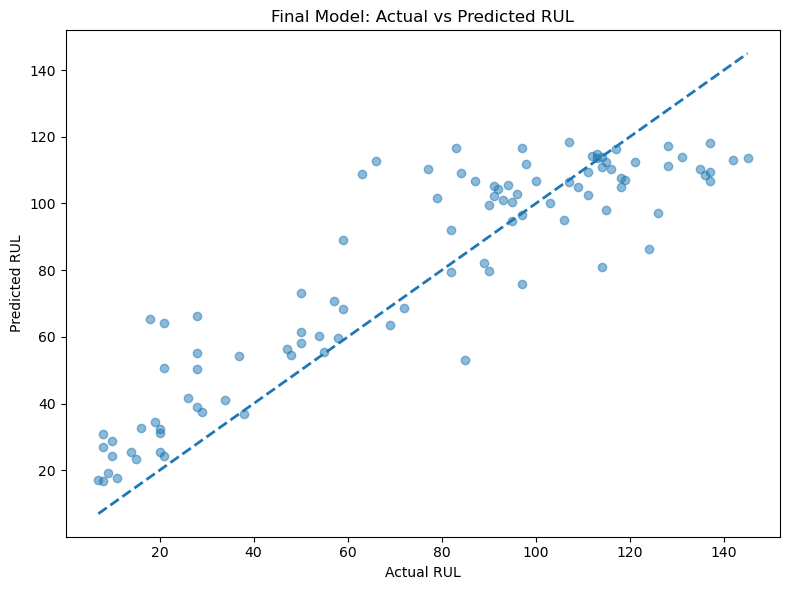

In [43]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_test_pred,
    alpha=0.5
)

min_val = min(y_test.min(), y_test_pred.min())
max_val = max(y_test.max(), y_test_pred.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    "--",
    linewidth=2
)

plt.xlabel("Actual RUL")
plt.ylabel("Predicted RUL")
plt.title("Final Model: Actual vs Predicted RUL")

plt.tight_layout()
plt.show()

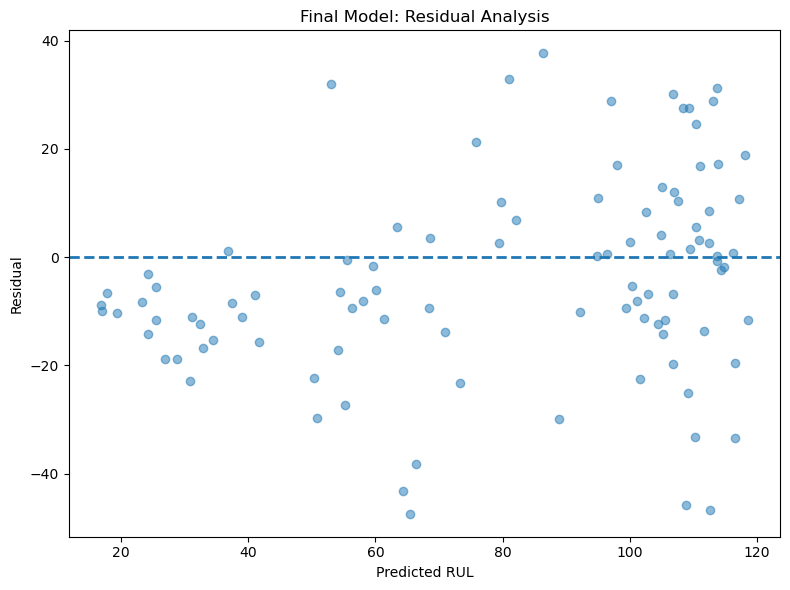

In [44]:
residuals = y_test - y_test_pred

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test_pred,
    residuals,
    alpha=0.5
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=2
)

plt.xlabel("Predicted RUL")
plt.ylabel("Residual")
plt.title("Final Model: Residual Analysis")

plt.tight_layout()
plt.show()